# 1. Bias Frame Analysis

This notebook is the first step in reducing CCD observations of the exoplanet host star **WASP-12**. The data were obtained on **2019-12-29** using the **AFOSC instrument** on the **1.82 m telescope** at the Asiago Astrophysical Observatory.

### Why bias frames?
CCD detectors have an inherent electronic offset (bias) that adds a constant pedestal to every pixel. Bias frames are zero‑exposure images taken with the shutter closed. They record:
 * The electronic bias level.
 * Readout noise characteristics.
 * Fixed pattern noise from the amplifier.
 
By combining multiple bias frames (typically using the **median** to reject outliers), we create a **master bias** that can be subtracted from all science, flat, and dark frames to remove this offset.

## Objectives

1. Import required libraries (`numpy`, `matplotlib`, `astropy.io.fits`).
2. Read a list of bias frame filenames.
3. Inspect one bias frame to understand its header and data.
4. Load all bias frames into a 3‑D stack and computes the median along the stack.
5. Visualise the resulting master bias.

In [1]:
# -----Imports-----
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits # Astropy FITS handling


# Plot style
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["EB Garamond", "Georgia", "Times New Roman"],
    # ---- Sizes ----
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.labelweight": "light",  # x/y labels
    "font.weight": "light",
    # ---- Axes/ticks style like the PDF ----
    "axes.edgecolor": "0.2",
    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    "axes.grid": False,
    "axes.labelcolor": "0.2",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "text.color": "0.2",
})


%matplotlib widget


In [8]:
# Read the list of bias frame filenames

bias_list = np.genfromtxt('./group15_WASP-12_20191229/bias/bias.list', dtype=str)


## Inspect a single bias frame


In [9]:
# Open the first bias frame
bias00_fits = fits.open('./group15_WASP-12_20191229/bias/' + bias_list[0])
bias00_hdu = bias00_fits[0]

# Print the header to understand the observation parameters
bias00_hdu.header


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                  521 / length of data axis 1                          
NAXIS2  =                  222 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
DATE    = '2019-12-29T23:10:36' / file creation date (YYYY-MM-DDThh:mm:ss UT)   
FILENAME= 'AF580596.fits'      / Original file name                             
TIMESYS = 'UTC     '        

In [10]:
# Extract important header keywords
bias00_time = bias00_hdu.header['JD']                     # Julian Date at start
bias00_airmass = bias00_hdu.header['AIRMASS']             # Airmass (not critical for bias)
bias00_gain = bias00_hdu.header['GAIN']                   # Gain [e-/ADU]
bias00_gain_comment = bias00_hdu.header.comments['GAIN']
bias00_readout_noise = bias00_hdu.header['RDNOISE']       # Readout noise [e-]
bias00_ron_comment = bias00_hdu.header.comments['RDNOISE']

print('Julian date      : {0:12.6f} JD'.format(bias00_time))
print('CCD Gain         : {0:4.2f} {1:.8s}'.format(bias00_gain, bias00_gain_comment))
print('CCD Readout noise: {0:4.2f} {1:.3s}'.format(bias00_readout_noise, bias00_ron_comment))
print('Airmass          : {0:4.2f}'.format(bias00_airmass))


Julian date      : 2458847.465683 JD
CCD Gain         : 1.91 [e/ADU] 
CCD Readout noise: 7.10 [e]
Airmass          : 1.04


In [11]:
# Image dimensions
bias00_naxis1 = bias00_hdu.header['NAXIS1']
bias00_naxis2 = bias00_hdu.header['NAXIS2']
print('Shape of the FITS image from the header : {0:4d} x {1:4d}'
      .format(bias00_naxis1, bias00_naxis2))


Shape of the FITS image from the header :  521 x  222


In [12]:
# Load the data and convert from ADU to electrons by multiplying by the gain
bias00_data = bias00_hdu.data * bias00_gain
print('Shape of the NumPy array extracted by astropy: {0:4d} x {1:4d}'
      .format(bias00_data.shape[0], bias00_data.shape[1]))
print('Our image is saved as a', type(bias00_data))


Shape of the NumPy array extracted by astropy:  222 x  521
Our image is saved as a <class 'numpy.ndarray'>


## Build a 3‑D stack of all bias frames

In [13]:
n_images = len(bias_list)
# Use the shape of the first image to initialise the stack
bias00_nparray_dim00, bias00_nparray_dim01 = np.shape(bias00_data)
stack = np.empty([n_images, bias00_nparray_dim00, bias00_nparray_dim01])

In [14]:
# Loop over all bias frames and load them into the stack
for i_bias, bias_name in enumerate(bias_list):
    bias_temp = fits.open('./group15_WASP-12_20191229/bias/' + bias_name)
    # Convert to electrons by multiplying by gain
    stack[i_bias, :, :] = bias_temp[0].data * bias_temp[0].header['GAIN']
    bias_temp.close()

print(f"Stack shape: {stack.shape}")

Stack shape: (30, 222, 521)


## Combine the stack to produce a master bias

In [16]:
# Median combination is robust against cosmic rays and other outliers.
median_bias = np.median(stack, axis=0)   # median along the image stack axis
print("Master bias shape:", median_bias.shape)


Master bias shape: (222, 521)


## Visualise the master bias

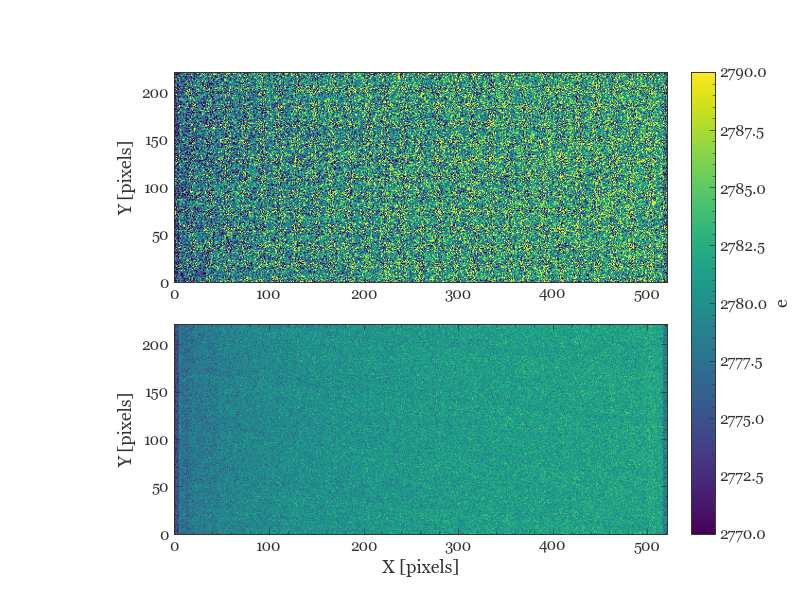

In [24]:
fig, ax = plt.subplots(2,1, figsize=(8,6)) 

im1 = ax[0].imshow(bias00_data, vmin = 2770, vmax =2790, origin='lower')
im2 = ax[1].imshow(median_bias, vmin = 2770, vmax =2790, origin='lower')


cbar = fig.colorbar(im1, ax=ax, cmap='magma',fraction=0.046, pad=0.04)
cbar.set_label("e")
ax[0].set_ylabel('Y [pixels]')
ax[1].set_xlabel('X [pixels]')
ax[1].set_ylabel('Y [pixels]')
plt.show()


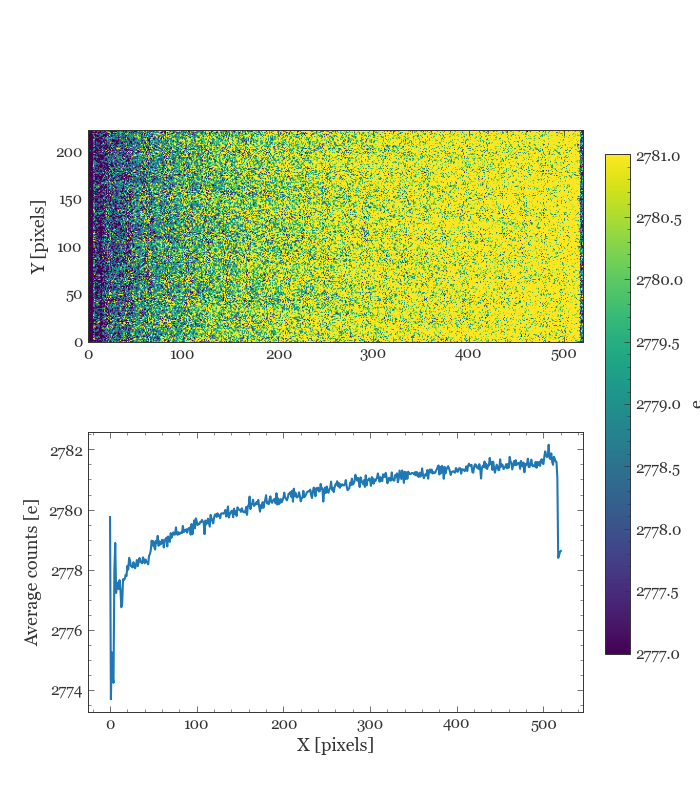

In [27]:
median_column = np.average(median_bias, axis=0)


fig, ax = plt.subplots(2,1, figsize=(7,8))

im1 = ax[0].imshow(median_bias, vmin = 2777, vmax =2781, origin='lower')
im2 = ax[1].plot(median_column)

cbar = fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

cbar.set_label("e")
ax[0].set_ylabel('Y [pixels]')
ax[1].set_xlabel('X [pixels]')
ax[1].set_ylabel('Average counts [e]')
plt.show()

## Basic statistics

In [30]:
print("Master bias statistics:")
print("  Mean     : {:.2f} e⁻".format(np.mean(median_bias)))
print("  Std. dev.: {:.2f} e⁻".format(np.std(median_bias)))
print("  Min      : {:.2f} e⁻".format(np.min(median_bias)))
print("  Max      : {:.2f} e⁻".format(np.max(median_bias)))

Master bias statistics:
  Mean     : 2780.38 e⁻
  Std. dev.: 2.07 e⁻
  Min      : 2769.50 e⁻
  Max      : 2788.60 e⁻


In [31]:
#  compare the readout noise as reported in the header of the fits frame 

starting_column= 300
ending_column = 350
print('1) Readout noise : {0:4.2f} e'.format(bias00_readout_noise))
print('2) STD single frame : {0:4.2f} e'.format(np.std(bias00_data[:,starting_column:ending_column])))

1) Readout noise : 7.10 e
2) STD single frame : 7.49 e


In [32]:
expected_noise_medianbias = bias00_readout_noise/np.sqrt(n_images)
print('1) Expected noise of median bias : {0:4.2f} e'.format(expected_noise_medianbias))
expected_std_medianbias = np.std(bias00_data[:,starting_column:ending_column])/np.sqrt(n_images)
print('2) Expected STD of median bias : {0:4.2f} e'.format(expected_std_medianbias))

1) Expected noise of median bias : 1.30 e
2) Expected STD of median bias : 1.37 e


In [33]:
measured_std_medianbias = np.std(median_bias[:,starting_column:ending_column])
print('Measured STD of median bias : {0:4.2f} e'.format(measured_std_medianbias))
median_error = np.std(stack, axis=0) /np.sqrt(n_images) # saved in a file
median_pixel_error = np.median(median_error) # saved
print('Median STD of each pixel : {0:4.2f} e'.format(median_pixel_error))

Measured STD of median bias : 1.69 e
Median STD of each pixel : 1.31 e


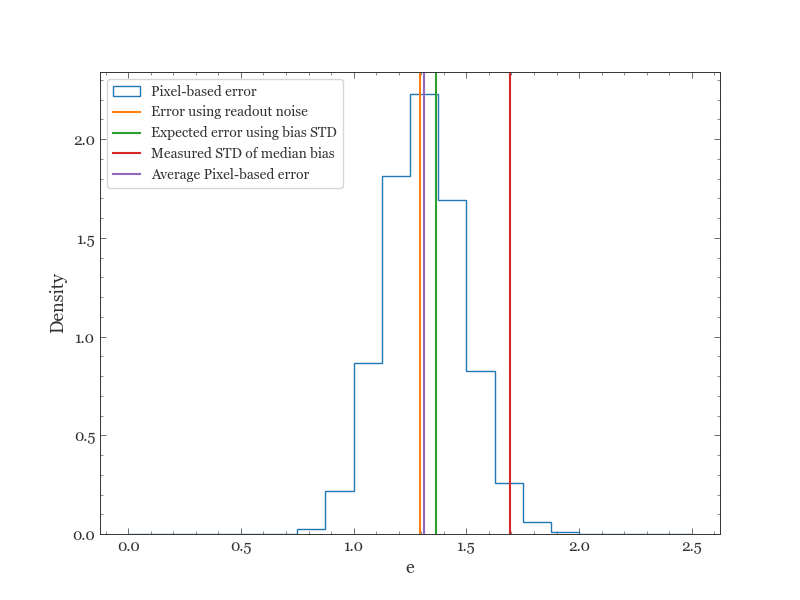

In [34]:
STD_pixel = np.std(stack, axis=0) 
plt.figure(figsize=(8,6))
plt.hist(median_error.flatten(), bins=20, range=(0,2.5), density=True,histtype='step', label='Pixel-based error')
plt.axvline(expected_noise_medianbias, c='C1', label='Error using readout noise')
plt.axvline(expected_std_medianbias, c='C2', label='Expected error using bias STD')
plt.axvline(measured_std_medianbias, c='C3', label='Measured STD of median bias')
plt.axvline(median_pixel_error, c='C4', label='Average Pixel-based error')
plt.xlabel('e')
plt.ylabel('Density')
plt.legend()
plt.show()

In [19]:
import pickle
# create a dictionary
pickle.dump(median_bias, open("median_bias.p","wb"))
pickle.dump(median_error, open("median_bias_error.p" ,"wb"))
pickle.dump(median_pixel_error, open("median_bias_error_value.p", "wb"))
pickle.dump(stack, open("stack_bias.p","wb"))

### Interpretation
 
The master bias shows the typical electronic offset of the detector. Its value will be subtracted from every subsequent calibration and science frame. The small residual structure (if any) is part of the fixed pattern noise. In the next notebooks we will use this master bias to correct:
* Dark frames (to remove the bias component from dark current).
* Flat fields (to isolate the pixel‑to‑pixel sensitivity variations).
* Science images (to obtain photometrically accurate fluxes).